# 04 — Objective, optimizer schedule, and token batching

> **Status:** implementation in progress.

- **Mapped issue:** [#11](https://github.com/majorgilles/transformer-2017-reproduction/issues/11)
- **Depends on:** `03_transformer.ipynb` / issue #5.


In [1]:
#| default_exp optimization


## Goal

Implement the 2017 objective/schedule and memory-safe batching primitives.


## Paper connection

Section 5.4 of *Attention Is All You Need* uses label smoothing with `ε_ls = 0.1`. The authors report that smoothing makes the model less certain, which hurts perplexity but improves accuracy and BLEU. The paper fixes the smoothing value but does not prescribe a particular software implementation.


## Label-smoothed loss

The Transformer returns logits shaped `(batch, target_length, vocabulary_size)`. We use PyTorch's built-in cross-entropy with the paper's label-smoothing value `ε = 0.1` from Section 5.4.

`label_smoothing` mixes the one-hot target with a uniform distribution over the vocabulary. `ignore_index` excludes padding positions from the loss. PyTorch expects the vocabulary dimension before the sequence dimension, so the wrapper transposes the logits from `(batch, target_length, vocabulary_size)` to `(batch, vocabulary_size, target_length)`.


In [2]:
#| export
import torch
import torch.nn.functional as F


def label_smoothed_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    pad_token_id: int,
    smoothing: float = 0.1,
) -> torch.Tensor:
    """Return mean label-smoothed loss over non-padding target positions.

    `logits` has shape `(batch, target_length, vocabulary_size)`, and
    `targets` has shape `(batch, target_length)`.
    """
    # Cross-entropy expects class scores shaped (batch, vocabulary, sequence),
    # so move the vocabulary axis before the target-length axis.
    return F.cross_entropy(
        logits.transpose(1, 2),
        targets,
        # Padding fills batch storage but does not represent a prediction target.
        ignore_index=pad_token_id,
        # Use the paper's regularization strength instead of a hard one-hot target.
        label_smoothing=smoothing,
    )

### Why use the built-in loss?

PyTorch already implements the numerically sensitive cross-entropy calculation and exposes the two behaviors needed here: `label_smoothing` and `ignore_index`. The small wrapper keeps this notebook's tensor-shape and padding conventions explicit without reimplementing a tested library operation. A later demonstration can construct a tiny smoothed target distribution by hand to reveal the idea while the exported training path remains simple.


In [3]:
vocabulary_size = 5
correct_token_id = 2
smoothing = 0.1

# PyTorch mixes a one-hot target with a uniform vocabulary distribution.
smoothed_target = torch.full(
    (vocabulary_size,),
    smoothing / vocabulary_size,
)
smoothed_target[correct_token_id] += 1.0 - smoothing

print("token ID | target probability")
for token_id, probability in enumerate(smoothed_target):
    marker = " ← correct" if token_id == correct_token_id else ""
    print(f"{token_id:>8} | {probability:.3f}{marker}")

assert torch.isclose(smoothed_target.sum(), torch.tensor(1.0))
assert torch.isclose(
    smoothed_target[correct_token_id],
    torch.tensor(1.0 - smoothing + smoothing / vocabulary_size),
)

token ID | target probability
       0 | 0.020
       1 | 0.020
       2 | 0.920 ← correct
       3 | 0.020
       4 | 0.020


### Padding does not affect the loss

The second position is padding. Computing the loss with or without that
position must produce the same result.

In [4]:
pad_token_id = 0

example_logits = torch.tensor(
    [
        [
            [0.2, -0.3, 1.4, 0.1, -0.2],
            [100.0, -50.0, 25.0, 10.0, -5.0],
        ]
    ]
)
example_targets = torch.tensor([[2, pad_token_id]])
print(example_targets.shape)

loss_with_padding = label_smoothed_loss(
    example_logits,
    example_targets,
    pad_token_id=pad_token_id,
)

loss_without_padding = label_smoothed_loss(
    example_logits[:, :1],
    example_targets[:, :1],
    pad_token_id=pad_token_id,
)

assert torch.isclose(loss_with_padding, loss_without_padding)

print(f"With padding:    {loss_with_padding:.4f}")
print(f"Without padding: {loss_without_padding:.4f}")

torch.Size([1, 2])
With padding:    0.7881
Without padding: 0.7881


## Transformer learning-rate schedule

Section 5.3 defines the learning rate as

$$
\text{lrate}
=
d_{\text{model}}^{-0.5}
\min\left(
\text{step}^{-0.5},
\text{step}\cdot\text{warmup}^{-1.5}
\right).
$$

The second term is smaller during warmup, so the learning rate rises linearly.
After warmup, the first term is smaller, so it falls with the inverse square
root of the step number. Steps begin at `1` because `0^{-0.5}` is undefined.

In [5]:
#| export
def noam_learning_rate(
    step: int,
    d_model: int,
    warmup_steps: int = 4_000,
) -> float:
    """Return the paper's learning rate for one optimizer step."""
    model_scale = d_model**-0.5
    decay = step**-0.5
    warmup = step * warmup_steps**-1.5

    return model_scale * min(decay, warmup)

In [6]:
example_d_model = 512
example_warmup_steps = 4_000

expected_rates = {
    1: (example_d_model**-0.5 * 1 * example_warmup_steps**-1.5),
    4_000: (example_d_model**-0.5 * example_warmup_steps**-0.5),
    8_000: (example_d_model**-0.5 * 8_000**-0.5),
}

actual_rates = {
    step: noam_learning_rate(
        step,
        d_model=example_d_model,
        warmup_steps=example_warmup_steps,
    )
    for step in expected_rates
}

print("step | learning rate")
for step, rate in actual_rates.items():
    print(f"{step:>4} | {rate:.8f}")
    assert abs(rate - expected_rates[step]) < 1e-12

assert actual_rates[1] < actual_rates[4_000]
assert actual_rates[8_000] < actual_rates[4_000]

step | learning rate
   1 | 0.00000017
4000 | 0.00069877
8000 | 0.00049411


### Reading the schedule values

At step `1`, the learning rate is only `0.00000017` because the linear warmup branch deliberately starts with a very small update. At the warmup boundary, step `4,000`, both branches of the formula are equal and the schedule reaches its peak of `0.00069877`.

After warmup, the inverse-square-root branch controls the schedule. Doubling the step from `4,000` to `8,000` multiplies the learning rate by `1 / √2 ≈ 0.707`, so `0.00069877` falls to approximately `0.00049411`. This rise-then-fall pattern is the intended behavior of the paper's schedule.


### Visible learning-rate curve

The curve should rise linearly until step `4,000` and then decrease with the
inverse square root of the step number. The dashed line marks the expected peak.

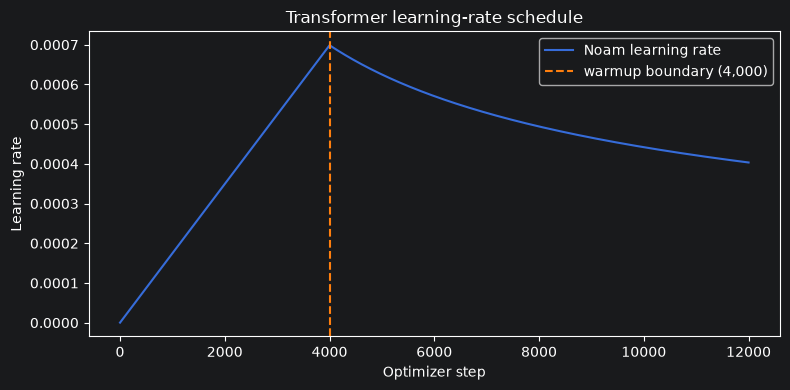

In [7]:
import matplotlib.pyplot as plt

plot_steps = list(range(1, 12_001))
plot_rates = [
    noam_learning_rate(
        step,
        d_model=example_d_model,
        warmup_steps=example_warmup_steps,
    )
    for step in plot_steps
]

peak_index = plot_rates.index(max(plot_rates))
peak_step = plot_steps[peak_index]

assert peak_step == example_warmup_steps

plt.figure(figsize=(8, 4))
plt.plot(plot_steps, plot_rates, label="Noam learning rate")
plt.axvline(
    example_warmup_steps,
    color="tab:orange",
    linestyle="--",
    label=f"warmup boundary ({example_warmup_steps:,})",
)
plt.xlabel("Optimizer step")
plt.ylabel("Learning rate")
plt.title("Transformer learning-rate schedule")
plt.legend()
plt.tight_layout()
plt.show()

## Adam optimizer settings

Section 5.3 uses Adam with

$$
\beta_1 = 0.9,\qquad
\beta_2 = 0.98,\qquad
\epsilon = 10^{-9}.
$$

`β₁` controls Adam's running average of gradients. `β₂` controls its running
average of squared gradients, which tracks their scale. `ε` is a tiny value
that prevents division by zero. The learning rate is not fixed: the Noam
schedule supplies a new value for every optimizer step.

In [8]:
example_parameter = torch.nn.Parameter(torch.tensor(0.0))

example_optimizer = torch.optim.Adam(
    [example_parameter],
    lr=noam_learning_rate(
        step=1,
        d_model=example_d_model,
        warmup_steps=example_warmup_steps,
    ),
    betas=(0.9, 0.98),
    eps=1e-9,
)

assert example_optimizer.defaults["betas"] == (0.9, 0.98)
assert example_optimizer.defaults["eps"] == 1e-9

print("Adam parameters")
print(f"betas: {example_optimizer.defaults['betas']}")
print(f"epsilon: {example_optimizer.defaults['eps']}")
print(f"initial learning rate: {example_optimizer.param_groups[0]['lr']:.8f}")

Adam parameters
betas: (0.9, 0.98)
epsilon: 1e-09
initial learning rate: 0.00000017


## Token-budget batching

Section 5.1 batches sentence pairs of similar lengths and uses approximately
25,000 source tokens and 25,000 target tokens per batch. Because each side is
padded to its longest sequence, we account for source and target storage
separately:

$$
\text{source positions}
=
\text{batch size}\times\text{maximum source length}
$$

$$
\text{target positions}
=
\text{batch size}\times\text{maximum target length}.
$$

The batcher only uses sequence lengths to decide which sentence pairs belong together. A later collation step creates the padded tensors. Keeping those responsibilities separate makes the batching rule easy to inspect and reuse.


In [9]:
#| export
from collections.abc import Sequence


def padded_token_counts(
    batch: Sequence[tuple[Sequence[int], Sequence[int]]],
) -> tuple[int, int]:
    """Return padded source and target token positions for one batch."""
    if not batch:
        return 0, 0

    batch_size = len(batch)
    maximum_source_length = max(len(source_ids) for source_ids, _ in batch)
    maximum_target_length = max(len(target_ids) for _, target_ids in batch)

    return (
        batch_size * maximum_source_length,
        batch_size * maximum_target_length,
    )

### Two sentence pairs become one padded batch

The two entries below are individual sentence pairs, not separate batches. Together they form one source batch and one target batch. ID `0` visibly fills the shorter rows so each tensor is rectangular.


In [10]:
example_batch = [
    ([11, 12, 13], [21, 22]),
    ([14, 15], [23, 24, 25, 26]),
]

# ID 0 represents padding.
padded_source_ids = torch.tensor(
    [
        [11, 12, 13],
        [14, 15, 0],
    ]
)
padded_target_ids = torch.tensor(
    [
        [21, 22, 0, 0],
        [23, 24, 25, 26],
    ]
)

source_positions, target_positions = padded_token_counts(example_batch)

assert source_positions == padded_source_ids.numel() == 6
assert target_positions == padded_target_ids.numel() == 8

print("One source batch:")
print(padded_source_ids)
print(f"shape: {tuple(padded_source_ids.shape)}, positions: {source_positions}")

print("\nOne target batch:")
print(padded_target_ids)
print(f"shape: {tuple(padded_target_ids.shape)}, positions: {target_positions}")

One source batch:
tensor([[11, 12, 13],
        [14, 15,  0]])
shape: (2, 3), positions: 6

One target batch:
tensor([[21, 22,  0,  0],
        [23, 24, 25, 26]])
shape: (2, 4), positions: 8


### Form batches without exceeding the budget

The batcher considers sentence pairs in their existing order. It adds the next pair when both padded counts fit. If either side would exceed the budget, it saves the current batch and starts a new one with that pair. Length grouping can happen before this helper; the helper itself does not reorder examples.


In [11]:
#| export
def make_token_budget_batches(
    examples: Sequence[tuple[Sequence[int], Sequence[int]]],
    token_budget: int,
) -> list[list[tuple[Sequence[int], Sequence[int]]]]:
    """Group ordered token pairs within a padded-token budget per side."""
    if token_budget < 1:
        raise ValueError("token_budget must be positive")

    batches: list[list[tuple[Sequence[int], Sequence[int]]]] = []
    current_batch: list[tuple[Sequence[int], Sequence[int]]] = []

    for example in examples:
        source_ids, target_ids = example
        if len(source_ids) > token_budget or len(target_ids) > token_budget:
            raise ValueError("one example exceeds the token budget")

        candidate_batch = [*current_batch, example]
        source_positions, target_positions = padded_token_counts(candidate_batch)
        candidate_exceeds_budget = (
            source_positions > token_budget or target_positions > token_budget
        )

        if current_batch and candidate_exceeds_budget:
            batches.append(current_batch)
            current_batch = [example]
        else:
            current_batch = candidate_batch

    if current_batch:
        batches.append(current_batch)

    return batches

### Pack sentence pairs into as few valid batches as possible

The goal is not to make one batch for every sentence pair. The goal is to process as many pairs together as possible without creating a padded source or target tensor larger than the budget. In the output below, **positions used of 6 allowed** reports tensor storage, not actual non-padding tokens. Each row remains one separate sentence.


In [12]:
# The IDs stand for these three translation examples:
# 101 102         -> 201 202          ("I run" -> "Ich laufe")
# 103 104 105     -> 203 204 205      ("You run fast" -> "Du läufst schnell")
# 106 107 108 109 -> 206 207 208 209  ("We walk to school" -> "Wir gehen zur Schule")
budget_examples = [
    ([101, 102], [201, 202]),
    ([103, 104, 105], [203, 204, 205]),
    ([106, 107, 108, 109], [206, 207, 208, 209]),
]
example_descriptions = [
    "I run -> Ich laufe",
    "You run fast -> Du läufst schnell",
    "We walk to school -> Wir gehen zur Schule",
]
example_token_budget = 6
budget_batches = make_token_budget_batches(
    budget_examples,
    token_budget=example_token_budget,
)

assert [example for batch in budget_batches for example in batch] == budget_examples
assert len(budget_batches) == 2
assert all(
    source_positions <= example_token_budget
    and target_positions <= example_token_budget
    for batch in budget_batches
    for source_positions, target_positions in [padded_token_counts(batch)]
)

next_example_index = 0
for batch_number, batch in enumerate(budget_batches, start=1):
    source_positions, target_positions = padded_token_counts(batch)
    maximum_source_length = max(len(source_ids) for source_ids, _ in batch)
    maximum_target_length = max(len(target_ids) for _, target_ids in batch)
    padded_sources = [
        [*source_ids, *(["PAD"] * (maximum_source_length - len(source_ids)))]
        for source_ids, _ in batch
    ]
    padded_targets = [
        [*target_ids, *(["PAD"] * (maximum_target_length - len(target_ids)))]
        for _, target_ids in batch
    ]

    print(f"\nBatch {batch_number} processes {len(batch)} pair(s) together:")
    for description in example_descriptions[
        next_example_index : next_example_index + len(batch)
    ]:
        print(f"  - {description}")
    print(f"  padded source rows: {padded_sources}")
    print(f"  source positions: {source_positions} used of 6 allowed")
    print(f"  padded target rows: {padded_targets}")
    print(f"  target positions: {target_positions} used of 6 allowed")
    next_example_index += len(batch)

all_three_source_positions, _ = padded_token_counts(budget_examples)
assert all_three_source_positions == 12
print(
    "\nAll three cannot share one batch: "
    "3 rows x longest row of 4 = 12 source positions, which exceeds 6."
)


Batch 1 processes 2 pair(s) together:
  - I run -> Ich laufe
  - You run fast -> Du läufst schnell
  padded source rows: [[101, 102, 'PAD'], [103, 104, 105]]
  source positions: 6 used of 6 allowed
  padded target rows: [[201, 202, 'PAD'], [203, 204, 205]]
  target positions: 6 used of 6 allowed

Batch 2 processes 1 pair(s) together:
  - We walk to school -> Wir gehen zur Schule
  padded source rows: [[106, 107, 108, 109]]
  source positions: 4 used of 6 allowed
  padded target rows: [[206, 207, 208, 209]]
  target positions: 4 used of 6 allowed

All three cannot share one batch: 3 rows x longest row of 4 = 12 source positions, which exceeds 6.


## Explicitly deferred

Training-loop orchestration, gradient accumulation, mixed precision,
checkpoint persistence, WMT training, and campaign freeze belong to later
notebooks.